# Old

In [4]:
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

# 假設你已經有一個 DataFrame 叫 df
df = pd.read_csv('./studentVle.csv', on_bad_lines='error')
df.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [6]:
# 先按特定欄位排序
df_sorted = df.sort_values(by=['code_module', 'code_presentation', 'id_student', 'id_site', 'date'])

# 新增一行，將相同日期但不同 id_site 的點擊次數合併加總
df_merged = df_sorted.groupby(['code_module', 'code_presentation', 'id_student', 'date']).agg(
    sum_click=('sum_click', 'sum')  # 合併同一天的點擊數
).reset_index()

# 計算日期間隔，現在不考慮 id_site
df_merged['date_diff'] = df_merged.groupby(['code_module', 'code_presentation', 'id_student'])['date'].diff()

# 計算平均間隔和標準差
interval_stats = df_merged.groupby(['code_module', 'code_presentation', 'id_student']).agg(
    mean_click_interval=('date_diff', 'mean'),
    std_click_interval=('date_diff', 'std')
).reset_index()

print(interval_stats)


      code_module code_presentation  id_student  mean_click_interval  \
0             AAA             2013J       11391             6.615385   
1             AAA             2013J       28400             3.151899   
2             AAA             2013J       30268             2.000000   
3             AAA             2013J       31604             2.245902   
4             AAA             2013J       32885             3.724638   
...           ...               ...         ...                  ...   
29223         GGG             2014J     2640965             5.750000   
29224         GGG             2014J     2645731             5.181818   
29225         GGG             2014J     2648187            10.304348   
29226         GGG             2014J     2679821             9.500000   
29227         GGG             2014J     2684003             7.090909   

       std_click_interval  
0                5.756531  
1                2.931214  
2                1.612452  
3                1.8952

In [7]:
df_merged.head()

,code_module,code_presentation,id_student,date,sum_click,date_diff
0,AAA,2013J,11391,-5,98,NaN
1,AAA,2013J,11391,0,49,5.0
2,AAA,2013J,11391,1,127,1.0
3,AAA,2013J,11391,2,4,1.0
4,AAA,2013J,11391,6,3,4.0


In [8]:
# 計算每個學生的平均點擊次數
mean_clicks = df_merged.groupby(['code_module', 'code_presentation', 'id_student'])['sum_click'].mean().reset_index()
interval_stats['mean_clicks'] = mean_clicks['sum_click']
interval_stats.head()

,code_module,code_presentation,id_student,mean_click_interval,std_click_interval,mean_clicks
0,AAA,2013J,11391,6.615385,5.756531,23.350000
1,AAA,2013J,28400,3.151899,2.931214,17.937500
2,AAA,2013J,30268,2.000000,1.612452,23.416667
3,AAA,2013J,31604,2.245902,1.895238,17.544715
4,AAA,2013J,32885,3.724638,3.883919,14.771429


In [9]:
import numpy as np

# 先按特定欄位排序
df_sorted = df.sort_values(by=['code_module', 'code_presentation', 'id_student', 'id_site', 'date'])

# 新增一行，將相同日期但不同 id_site 的點擊次數合併加總
df_merged = df_sorted.groupby(['code_module', 'code_presentation', 'id_student', 'date']).agg(
    sum_click=('sum_click', 'sum')  # 合併同一天的點擊數
).reset_index()

# 建立每個學生的完整日期範圍，並補上缺失的日期（填補 0 點擊的天數）
def create_full_date_range(group):
    # 建立完整的日期範圍，從最小到最大的日期
    full_range = pd.DataFrame({'date': range(group['date'].min(), group['date'].max() + 1)})
    return full_range.merge(group, on='date', how='left').fillna({'sum_click': 0})

# 對每個學生建立完整的日期範圍並補上點擊數 0 的天數
df_full = df_merged.groupby(['code_module', 'code_presentation', 'id_student']).apply(create_full_date_range).reset_index(drop=True)

# 計算變異係數
df_full['click_variance'] = df_full.groupby(['code_module', 'code_presentation', 'id_student'])['sum_click'].transform(lambda x: np.std(x) / np.mean(x) if np.mean(x) != 0 else 0)

# 獲取每個學生的變異係數
variance_stats = df_full.groupby(['code_module', 'code_presentation', 'id_student']).agg(
    click_variance=('click_variance', 'first')  # 每個學生的變異係數
).reset_index()

print(variance_stats)


/var/folders/_q/xfvw_6_d3c5b8t1lpm7rppnh0000gn/T/ipykernel_4338/319899792.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_full = df_merged.groupby(['code_module', 'code_presentation', 'id_student']).apply(create_full_date_range).reset_index(drop=True)


      code_module code_presentation  id_student  click_variance
0             AAA             2013J     11391.0        1.176466
1             AAA             2013J     28400.0        1.143786
2             AAA             2013J     30268.0        0.705049
3             AAA             2013J     31604.0        0.863160
4             AAA             2013J     32885.0        1.116342
...           ...               ...         ...             ...
29223         GGG             2014J   2640965.0        0.842788
29224         GGG             2014J   2645731.0        1.575726
29225         GGG             2014J   2648187.0        1.070954
29226         GGG             2014J   2679821.0        1.068831
29227         GGG             2014J   2684003.0        0.734900

[29228 rows x 4 columns]


In [10]:
interval_stats['click_variance'] = variance_stats['click_variance']
interval_stats.head()

,code_module,code_presentation,id_student,mean_click_interval,std_click_interval,mean_clicks,click_variance
0,AAA,2013J,11391,6.615385,5.756531,23.350000,1.176466
1,AAA,2013J,28400,3.151899,2.931214,17.937500,1.143786
2,AAA,2013J,30268,2.000000,1.612452,23.416667,0.705049
3,AAA,2013J,31604,2.245902,1.895238,17.544715,0.863160
4,AAA,2013J,32885,3.724638,3.883919,14.771429,1.116342


In [11]:
# 定義 Gini 係數的計算函數
def gini_coefficient(x):
    # 排序數據
    x_sorted = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x_sorted)  # 累加點擊次數
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

# 計算 Gini 係數
df_full['gini'] = df_full.groupby(['code_module', 'code_presentation', 'id_student'])['sum_click'].transform(lambda x: gini_coefficient(x))

# 獲取每個學生的 Gini 係數
gini_stats = df_full.groupby(['code_module', 'code_presentation', 'id_student']).agg(
    gini_clicks=('gini', 'first')  # 每個學生的 Gini 係數
).reset_index()

print(gini_stats)


      code_module code_presentation  id_student  gini_clicks
0             AAA             2013J     11391.0     0.565364
1             AAA             2013J     28400.0     0.560270
2             AAA             2013J     30268.0     0.398873
3             AAA             2013J     31604.0     0.462262
4             AAA             2013J     32885.0     0.515059
...           ...               ...         ...          ...
29223         GGG             2014J   2640965.0     0.448780
29224         GGG             2014J   2645731.0     0.676621
29225         GGG             2014J   2648187.0     0.555288
29226         GGG             2014J   2679821.0     0.551049
29227         GGG             2014J   2684003.0     0.406608

[29228 rows x 4 columns]


In [12]:
interval_stats['gini_clicks'] = gini_stats['gini_clicks']
interval_stats.head()

,code_module,code_presentation,id_student,mean_click_interval,std_click_interval,mean_clicks,click_variance,gini_clicks
0,AAA,2013J,11391,6.615385,5.756531,23.350000,1.176466,0.565364
1,AAA,2013J,28400,3.151899,2.931214,17.937500,1.143786,0.560270
2,AAA,2013J,30268,2.000000,1.612452,23.416667,0.705049,0.398873
3,AAA,2013J,31604,2.245902,1.895238,17.544715,0.863160,0.462262
4,AAA,2013J,32885,3.724638,3.883919,14.771429,1.116342,0.515059


In [13]:
interval_stats.size

233824

In [14]:
interval_stats.to_csv('student_click_stats.csv', index=False)

In [11]:
import pandas as pd

studentInfo = pd.read_csv('studentInfo.csv')
studentAssess = pd.read_csv('studentAssessment.csv')
assessments = pd.read_csv('assessments.csv')
studentRegistration = pd.read_csv('studentRegistration.csv')
studentClick = pd.read_csv('student_click_stats.csv')

# keep only 'assessment_type' == 'Exam' in assessments
assessments = assessments[assessments['assessment_type'] == 'Exam']

merged_df = pd.merge(assessments, studentAssess, on=['id_assessment'], how='inner')
merged_df = pd.merge(merged_df, studentInfo, on=['code_module', 'code_presentation', 'id_student'], how='left')
# merged_df = pd.merge(merged_df, assessments, on=['code_module', 'code_presentation', 'id_assessment'], how='outer')
merged_df = pd.merge(merged_df, studentRegistration, on=['code_module', 'code_presentation', 'id_student'], how='left')
merged_df = pd.merge(merged_df, studentClick, on=['code_module', 'code_presentation', 'id_student'], how='left')

merged_df.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score,...,studied_credits,disability,final_result,date_registration,date_unregistration,mean_click_interval,std_click_interval,mean_clicks,click_variance,gini_clicks
0,CCC,2014B,24290,Exam,NaN,100.0,558914,230,0,32.0,...,90,N,Fail,-74.0,NaN,1.505814,1.162258,16.485549,1.898424,0.594006
1,CCC,2014B,24290,Exam,NaN,100.0,559706,234,0,78.0,...,30,N,Pass,-22.0,NaN,4.754717,5.409769,26.500000,1.105577,0.579768
2,CCC,2014B,24290,Exam,NaN,100.0,559770,230,0,54.0,...,60,N,Pass,-22.0,NaN,1.446927,1.055339,25.716667,1.751960,0.644510
3,CCC,2014B,24290,Exam,NaN,100.0,560114,230,0,64.0,...,30,Y,Pass,-281.0,NaN,1.840580,1.539013,17.575540,1.298497,0.561929
4,CCC,2014B,24290,Exam,NaN,100.0,560311,234,0,100.0,...,60,N,Distinction,-28.0,NaN,2.398148,3.629937,28.266055,1.818213,0.691131


In [20]:
# test = pd.merge(assessments, studentAssess, on=['id_assessment'], how='inner')
# show unique values of 'id_assessment' in test
print(test['id_assessment'].unique())

[24290 24299 25340 25354 25361 25368]


In [19]:
# print all sizes of dataframes
print(studentInfo.size, studentAssess.size, assessments.size, studentRegistration.size, studentClick.size, merged_df.size)

391116 869560 144 162965 233824 128934


In [20]:
merged_df.to_csv('dataMerged.csv', index=False)

# Parallel Plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 讀取資料
student_assessments = pd.read_csv('studentAssessment.csv')
assessments = pd.read_csv('assessments.csv')

# 合併資料
merged_data = pd.merge(student_assessments, assessments, on='id_assessment')

# 過濾出期末考（assessment_type = 'Exam'）
exam_data = merged_data[merged_data['assessment_type'] == 'Exam'].copy()  # 使用 copy() 創建副本

# 去除沒有 'Exam' 成績的學生
exam_data = exam_data.dropna(subset=['score'])

# 轉換 'score' 為數字型態
exam_data['score'] = pd.to_numeric(exam_data['score'], errors='coerce')

# 依照 'score' 分成五群
exam_data_sorted = exam_data.sort_values(by='score', ascending=False)

# 分五群（每群人數相同）
num_groups = 5
exam_data_sorted['score_group'] = pd.qcut(exam_data_sorted['score'], num_groups, labels=False)

# 把分群結果合併回 merged_data
merged_data = pd.merge(merged_data, exam_data_sorted[['id_student', 'score_group', 'code_module', 'code_presentation']], 
                       on=['id_student', 'code_module', 'code_presentation'], how='inner')

# 過濾出期末考之外的成績
non_exam_data = merged_data[merged_data['assessment_type'] != 'Exam'].copy()

# 確保 'date_submitted' 欄位有有效的資料，並去除缺失的資料
non_exam_data = non_exam_data.dropna(subset=['date_submitted'])
# 進行每個學生的 date_submitted 值比例轉換至 0 到 100 之間
non_exam_data['date_submitted_normalized'] = non_exam_data.groupby(['id_student', 'code_module', 'code_presentation'])['date_submitted'].transform(
    lambda x: (x - x.min()) * 100 / (x.max() - x.min())
)

# 繪製折線圖
plt.figure(figsize=(10, 6))

count = 0
# 繪製每個學生的學習狀況
for _, student_data in non_exam_data.groupby(['id_student', 'code_module', 'code_presentation']):
    if (student_data['score_group'].nunique() == 1) and (student_data['score_group'].iloc[0] != 0): continue # 只畫第五群的學生
    count += 1
    if count > 20: break  # 限制繪製的學生數量
    student_data = student_data.sort_values(by='date_submitted_normalized')  # 依日期排序
    plt.plot(student_data['date_submitted_normalized'], student_data['score'], color=plt.cm.viridis(student_data['score_group'].iloc[0] / 4), alpha=0.7)

print(count)

# 設定圖表標題和軸標籤
plt.title('Student Performance Over Time Based on Final Exam Score Groups')
plt.xlabel('Date')
plt.ylabel('Score')
plt.yticks(np.arange(0, 101, 20))  # 設定 y 軸範圍和刻度

# 顯示圖例
handles = [plt.Line2D([0], [0], color=plt.cm.viridis(i / 4), lw=2) for i in range(num_groups)]
labels = [f'Group {i+1}' for i in range(num_groups)]
plt.legend(handles, labels, title='Final Exam Score Groups')

# 顯示圖表
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 讀取資料
student_assessments = pd.read_csv('studentAssessment.csv')
assessments = pd.read_csv('assessments.csv')
merged_data = pd.merge(student_assessments, assessments, on='id_assessment')
vle = pd.read_csv('studentVLE.csv')

# 1. 先把同一天的點擊合併（依據 "code_module","code_presentation","id_student", "date"）
vle = vle.groupby(["code_module", "code_presentation", "id_student", "date"], as_index=False).agg({"sum_click": "sum"})

# 2. 針對每位學生(同一個 "code_module", "code_presentation", "id_student")，依日期排序
vle = vle.sort_values(["code_module", "code_presentation", "id_student", "date"])

# 3. 利用 groupby 計算相鄰兩筆記錄的日期差（即兩次點擊記錄的間隔天數）
vle["date_interval"] = vle.groupby(["code_module", "code_presentation", "id_student"])["date"].diff()

# 若需要刪除第一筆記錄（因為 diff 會產生 NaN），可以這樣處理：
intervals = vle.dropna(subset=["date_interval"])

# 此時 df_intervals 就是一個紀錄點擊間隔的表格，包含每位學生在不同天的點擊記錄之間相差多少天。

# 依照 期末考分數 分成五群
exam_data = merged_data[merged_data['assessment_type'] == 'Exam'].copy()  # 使用 copy() 創建副本
exam_data = exam_data.dropna(subset=['score'])
exam_data['score'] = pd.to_numeric(exam_data['score'], errors='coerce')
exam_data_sorted = exam_data.sort_values(by='score', ascending=False)
num_groups = 5
exam_data_sorted['score_group'] = pd.qcut(exam_data_sorted['score'], num_groups, labels=False)

# 把分群結果合併回 merged_data
merged_data = pd.merge(intervals, exam_data_sorted[['id_student', 'score_group', 'code_module', 'code_presentation']], 
                       on=['id_student', 'code_module', 'code_presentation'], how='inner')

# 繪製折線圖
plt.figure(figsize=(10, 6))

count = 0
# 繪製每個學生的學習狀況
for _, student_data in merged_data.groupby(['id_student', 'code_module', 'code_presentation']):
    if (student_data['score_group'].nunique() == 1) and (student_data['score_group'].iloc[0] != 1): continue # 只畫第五群的學生
    count += 1
    if count > 3: break  # 限制繪製的學生數量
    plt.plot(range(len(student_data['date_interval'])), student_data['date_interval'], color=plt.cm.viridis(student_data['score_group'].iloc[0] / 4), alpha=0.7)

print(count)

# 設定圖表標題和軸標籤
plt.title('Student\'s Clicks Events Interval Over Time Based on Final Exam Score Groups')
plt.ylabel('Interval (days)')
# plt.yticks(np.arange(0, 251, 50))  # 設定 y 軸範圍和刻度

# 顯示圖例
handles = [plt.Line2D([0], [0], color=plt.cm.viridis(i / 4), lw=2) for i in range(num_groups)]
labels = [f'Group {i+1}' for i in range(num_groups)]
plt.legend(handles, labels, title='Final Exam Score Groups')

# 顯示圖表
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Scatter Plot

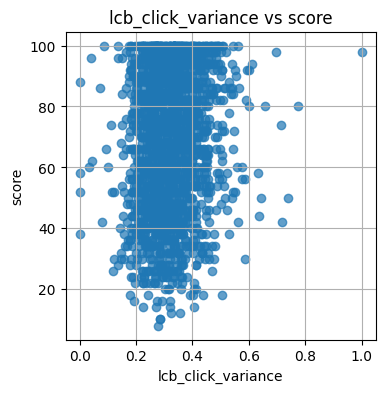

In [22]:
# import matplotlib.pyplot as plt
# import pandas as pd

# data_path = 'data_0412a.csv'

# df = pd.read_csv(data_path)

# 選兩個欄位
x_col = 'lcb_click_variance'
y_col = 'score'

# 畫圖
plt.figure(figsize=(4, 4))
plt.scatter(df[x_col], df[y_col], alpha=0.7)
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f'{x_col} vs {y_col}')
plt.grid(True)
plt.show()


# New

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np

In [2]:
export_name = 'data_0514_2c.csv'
class_num = 3

studentInfo = pd.read_csv('studentInfo.csv')
studentAssess = pd.read_csv('studentAssessment.csv')
assessments = pd.read_csv('assessments.csv')
studentRegistration = pd.read_csv('studentRegistration.csv')

# keep only 'assessment_type' == 'Exam' in assessments
assessments = assessments[assessments['assessment_type'] == 'Exam']

merged_df = pd.merge(assessments, studentAssess, on=['id_assessment'], how='inner')
merged_df = pd.merge(merged_df, studentInfo, on=['code_module', 'code_presentation', 'id_student'], how='left')
merged_df = pd.merge(merged_df, studentRegistration, on=['code_module', 'code_presentation', 'id_student'], how='left')

print(merged_df.shape)
merged_df.head()

(4959, 21)


,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score,...,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
0,CCC,2014B,24290,Exam,NaN,100.0,558914,230,0,32.0,...,North Western Region,A Level or Equivalent,10-20,0-35,0,90,N,Fail,-74.0,NaN
1,CCC,2014B,24290,Exam,NaN,100.0,559706,234,0,78.0,...,East Midlands Region,Lower Than A Level,60-70%,0-35,0,30,N,Pass,-22.0,NaN
2,CCC,2014B,24290,Exam,NaN,100.0,559770,230,0,54.0,...,South East Region,HE Qualification,90-100%,35-55,0,60,N,Pass,-22.0,NaN
3,CCC,2014B,24290,Exam,NaN,100.0,560114,230,0,64.0,...,North Western Region,A Level or Equivalent,10-20,0-35,0,30,Y,Pass,-281.0,NaN
4,CCC,2014B,24290,Exam,NaN,100.0,560311,234,0,100.0,...,East Anglian Region,Lower Than A Level,50-60%,0-35,0,60,N,Distinction,-28.0,NaN


# Normalization

In [3]:
def normalize(df):
    df = merged_df.copy()
    # df = pd.read_csv('dataMerged.csv')

    # 找出非 nominal 欄位（數值欄位，但排除 nominal 和 target 欄位，如果你有一個叫 'score' 的 target 欄位）
    non_nominal_cols = df.select_dtypes(include=['number']).columns.difference(['score', 'avg_score', 'completion_ratio', 'id_student', 'score_diff'])

    # 初始化 scaler
    scaler = MinMaxScaler()

    # 對非 nominal 欄位做 normalization，並直接覆蓋原欄位
    df[non_nominal_cols] = scaler.fit_transform(df[non_nominal_cols])

    print(df.describe())
    return df

# Assessments Stats

In [4]:
# 讀檔
assessments = pd.read_csv('assessments.csv')
student_assessments = pd.read_csv('studentAssessment.csv')

# 篩出非考試類型的作業
assignments_only = assessments[assessments['assessment_type'] != 'Exam']

# 建立學生與作業的 Cartesian join（所有學生該門課應該繳交的所有作業）
expected = pd.merge(
    student_assessments[['id_student']].drop_duplicates(),
    assignments_only,
    how='cross'  # 或改用自己控制範圍的 merge
)

# 合併實際繳交資料（左邊保留所有應繳交作業）
full_data = pd.merge(
    assignments_only,
    student_assessments,
    on='id_assessment',
    how='left',
    suffixes=('_assessment', '_student')
)

# 計算遲交欄位：僅當有繳交時再判斷
full_data['is_late'] = (full_data['date_submitted'] > full_data['date']) & full_data['date_submitted'].notna()

# 補上沒繳交的學生：用 assessments 去對 studentAssessment 的學生和作業做 Cartesian join
students = student_assessments[['id_student']].drop_duplicates()
assignment_students = pd.merge(assignments_only, students, how='cross')

# 合併應繳資料與實際繳交情況（左邊是所有應該出現的 student-assignment 組合）
complete = pd.merge(
    assignment_students,
    full_data[['id_assessment', 'id_student', 'score', 'is_late']],
    on=['id_assessment', 'id_student'],
    how='left'
)

# 最終彙總：每位學生在每門課的資料
ass_stats = complete.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_submissions=('score', lambda x: x.notna().sum()),
    total_late=('is_late', lambda x: x.fillna(False).sum()),
    avg_score=('score', 'mean'),
    expected_assignments=('id_assessment', 'count')
).reset_index()

# 補上完成比例
ass_stats['late_ratio'] = ass_stats['total_late'] / ass_stats['total_submissions']
ass_stats['completion_ratio'] = ass_stats['total_submissions'] / ass_stats['expected_assignments']
ass_stats.drop(columns=['expected_assignments', 'total_late', 'total_submissions'], inplace=True)

# 顯示
ass_stats.head()

/var/folders/_q/xfvw_6_d3c5b8t1lpm7rppnh0000gn/T/ipykernel_1369/3771803210.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  total_late=('is_late', lambda x: x.fillna(False).sum()),


,id_student,code_module,code_presentation,avg_score,late_ratio,completion_ratio
0,6516,AAA,2013J,NaN,NaN,0.0
1,6516,AAA,2014J,61.8,0.0,1.0
2,6516,BBB,2013B,NaN,NaN,0.0
3,6516,BBB,2013J,NaN,NaN,0.0
4,6516,BBB,2014B,NaN,NaN,0.0


In [5]:
merged_df = pd.merge(merged_df, ass_stats, on=['code_module', 'code_presentation', 'id_student'], how='left')
print(merged_df.shape)

(4959, 24)


# Feature Fusion on Click Stats

In [6]:
# activity_to_category = {
#     'homepage': 'LPB',
#     'page': 'LPB',
#     'subpage': 'LPB',
#     'sharedsubpage': 'LPB',
#     'resource': 'KAB',
#     'oucontent': 'KAB',
#     'htmlactivity': 'KAB',
#     'url': 'KAB',
#     'glossary': 'KAB',
#     'folder': 'KAB',
#     'dataplus': 'KAB',
#     'ouwiki': 'KAB',
#     'dualpane': 'KAB',
#     'forumng': 'ILB',
#     'oucollaborate': 'ILB',
#     'ouelluminate': 'ILB',
#     'quiz': 'LCB',
#     'externalquiz': 'LCB',
#     'questionnaire': 'LCB',
#     'repeatactivity': 'LCB',
# }
# category = ['ALL', 'LPB', 'KAB', 'ILB', 'LCB']

In [7]:
activity_to_category = {
    'homepage': 'HOMEPAGE',
    'page': 'INPUT',
    'subpage': 'INPUT',
    'sharedsubpage': 'INPUT',
    'resource': 'INPUT',
    'oucontent': 'INPUT',
    'htmlactivity': 'INPUT',
    'url': 'INPUT',
    'glossary': 'INPUT',
    'folder': 'INPUT',
    'dataplus': 'INPUT',
    'ouwiki': 'INPUT',
    'dualpane': 'INPUT',
    'forumng': 'OUTPUT',
    'oucollaborate': 'OUTPUT',
    'ouelluminate': 'OUTPUT',
    'quiz': 'OUTPUT',
    'externalquiz': 'OUTPUT',
    'questionnaire': 'OUTPUT',
    'repeatactivity': 'OUTPUT',
}

category = ['HOMEPAGE', 'INPUT', 'OUTPUT']

## 不同學習行為類型的分佈

In [8]:
# 上傳必要的檔案
df_path = "./studentVle.csv"
vle_path = "./vle.csv"

# 讀取資料
df = pd.read_csv(df_path)
vle = pd.read_csv(vle_path)

# 合併 activity_type
df = pd.merge(df, vle[['id_site', 'activity_type']], on='id_site', how='left')

# 加入分類欄位
df['category'] = df['activity_type'].map(activity_to_category)

# 結果表格初始化
final_results = []

# 對四大類別 + 全部做統計
for cat in category:
    if cat == 'ALL':
        subset = df.copy()
    else:
        subset = df[df['category'] == cat]
    
    # 按日期合併點擊數
    df_sorted = subset.sort_values(by=['code_module', 'code_presentation', 'id_student', 'id_site', 'date'])
    df_merged = df_sorted.groupby(['code_module', 'code_presentation', 'id_student', 'date']).agg(
        sum_click=('sum_click', 'sum')
    ).reset_index()

    # 日期間隔計算
    df_merged['date_diff'] = df_merged.groupby(['code_module', 'code_presentation', 'id_student'])['date'].diff()

    # 間隔統計
    interval_stats = df_merged.groupby(['code_module', 'code_presentation', 'id_student']).agg(
        mean_click_interval=('date_diff', 'mean'),
        std_click_interval=('date_diff', 'std'),
        mean_clicks=('sum_click', 'mean')
    ).reset_index()

    # 建立完整日期範圍
    def create_full_date_range(group):
        full_range = pd.DataFrame({'date': range(group['date'].min(), group['date'].max() + 1)})
        return full_range.merge(group, on='date', how='left').fillna({'sum_click': 0})

    df_full = df_merged.groupby(['code_module', 'code_presentation', 'id_student']).apply(create_full_date_range).reset_index(drop=True)

    # 變異係數計算
    df_full['click_variance'] = df_full.groupby(['code_module', 'code_presentation', 'id_student'])['sum_click'].transform(
        lambda x: np.std(x) / np.mean(x) if np.mean(x) != 0 else 0
    )

    variance_stats = df_full.groupby(['code_module', 'code_presentation', 'id_student']).agg(
        click_variance=('click_variance', 'first')
    ).reset_index()

    # 合併所有統計結果
    summary = pd.merge(interval_stats, variance_stats, on=['code_module', 'code_presentation', 'id_student'])
    summary.columns = ['code_module', 'code_presentation', 'id_student'] + [f'{cat.lower()}_{col}' for col in summary.columns[3:]]

    final_results.append(summary)

# 合併所有類別的統計結果
from functools import reduce
click_stats = reduce(lambda left, right: pd.merge(left, right, on=['code_module', 'code_presentation', 'id_student'], how='outer'), final_results)


/var/folders/_q/xfvw_6_d3c5b8t1lpm7rppnh0000gn/T/ipykernel_1369/130814166.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_full = df_merged.groupby(['code_module', 'code_presentation', 'id_student']).apply(create_full_date_range).reset_index(drop=True)
/var/folders/_q/xfvw_6_d3c5b8t1lpm7rppnh0000gn/T/ipykernel_1369/130814166.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_full = df_merged.gro

In [9]:
merged_df = pd.merge(merged_df, click_stats, on=['code_module', 'code_presentation', 'id_student'], how='left')
print(merged_df.shape)

(4959, 36)


## 不同學習行為類型的比例

In [10]:
# 假設 df 是學生成績和行為的資料，vle 是提供資源的資料
# 讀取資料
df = pd.read_csv('studentVle.csv')
vle = pd.read_csv('vle.csv')
vle = vle.merge(df, on=['id_site', "code_module","code_presentation"], how='inner')

# 1. 計算每堂課提供的各資源類型比例
# 首先，將每個 id_site 與對應的資源類型對應起來
vle['category'] = vle['activity_type'].map(activity_to_category)

# 計算每堂課的各資源類型的點擊數總和
resource_proportions = vle.groupby(['code_module', 'code_presentation', 'category']).agg(
    total_clicks=('sum_click', 'sum')
).reset_index()

# 計算每堂課總點擊數
total_clicks_per_class = resource_proportions.groupby(['code_module', 'code_presentation'])['total_clicks'].sum().reset_index()
total_clicks_per_class.rename(columns={'total_clicks': 'class_total_clicks'}, inplace=True)

# 合併每堂課的總點擊數到資源比例資料中
resource_proportions = pd.merge(resource_proportions, total_clicks_per_class, on=['code_module', 'code_presentation'])

# 計算每堂課每類資源的比例
resource_proportions['resource_ratio'] = resource_proportions['total_clicks'] / resource_proportions['class_total_clicks']

# 2. 計算每位學生對不同資源類型的點擊比例
student_resource_proportions = vle.groupby(['id_student', 'code_module', 'code_presentation', 'category']).agg(
    student_clicks=('sum_click', 'sum')
).reset_index()

# 計算每個學生在每堂課的總點擊數
student_total_clicks = student_resource_proportions.groupby(['id_student', 'code_module', 'code_presentation'])['student_clicks'].sum().reset_index()
student_total_clicks.rename(columns={'student_clicks': 'student_total_clicks'}, inplace=True)

# 合併每個學生的總點擊數到學生資源比例資料中
student_resource_proportions = pd.merge(student_resource_proportions, student_total_clicks, on=['id_student', 'code_module', 'code_presentation'])

# 計算每位學生對不同資源類型的比例
student_resource_proportions['student_resource_ratio'] = student_resource_proportions['student_clicks'] / student_resource_proportions['student_total_clicks']

# 3. 計算每位學生對每類資源的點擊比例與該班級提供資源比例的對比
final_result = pd.merge(student_resource_proportions, resource_proportions[['code_module', 'code_presentation', 'category', 'resource_ratio']], 
                        on=['code_module', 'code_presentation', 'category'])

# 計算可比較的比例（學生比例 / 該班級的比例）
final_result['normalized_resource_ratio'] = final_result['student_resource_ratio'] / final_result['resource_ratio']

# 4. 將結果轉換為寬格式
# 先做 pivot
wide = final_result.pivot_table(
    index=['code_module', 'code_presentation', 'id_student'],
    columns='category',
    values=['student_resource_ratio',], # 'resource_ratio', 'normalized_resource_ratio'
    fill_value=0
)

# 把 MultiIndex 的欄位壓平，改成 "kab_resource_ratio" 這種形式
wide.columns = [
    f"{cat.lower()}_{metric}"
    for metric, cat in wide.columns
]
wide = wide.reset_index()

In [11]:
merged_df = pd.merge(merged_df, wide, on=['code_module', 'code_presentation', 'id_student'], how='left')
print(merged_df.shape)

(4959, 39)


# 標準化差值

In [12]:
# # 讀取資料
# student_assessments = pd.read_csv('studentAssessment.csv')
# assessments = pd.read_csv('assessments.csv')
# assessments = assessments[assessments['assessment_type'] != 'Exam']
# merged_data = pd.merge(student_assessments, assessments, on='id_assessment')

# merged_data['z_score'] = merged_data.groupby(['code_module', 'code_presentation'])['score'].transform(lambda x: (x - x.mean()) / x.std())

# # 對每位學生在每班的作業依日期排序
# merged_data = merged_data.sort_values(by=['code_module', 'code_presentation', 'id_student', 'date'])

# # 4. 找出每個學生在每班的第一筆與最後一筆作業分數（z_score）
# exam_data = merged_data.groupby(['code_module', 'code_presentation', 'id_student']).agg(
#     first_score=('score', 'first'),
#     last_score=('score', 'last')
# ).reset_index()

# # 5. 計算成績差異
# exam_data['score_diff'] = exam_data['last_score'] - exam_data['first_score']

# # 依照 期末考分數 分成五群
# # exam_data = merged_data[merged_data['assessment_type'] == 'Exam'].copy()  # 使用 copy() 創建副本
# exam_data = exam_data.dropna(subset=['score_diff'])
# # exam_data['score'] = pd.to_numeric(exam_data['score'], errors='coerce')
# exam_data_sorted = exam_data.sort_values(by='score_diff', ascending=False)
# exam_data.drop(columns=['first_score', 'last_score'], inplace=True)

In [13]:
# merged_df = pd.merge(merged_df, exam_data, on=['code_module', 'code_presentation', 'id_student'], how='left')
# print(merged_df.shape)

# 不同階段的平均成績

In [14]:
assessments = pd.read_csv('assessments.csv')
assessments = assessments[assessments['assessment_type'] != 'Exam']
student_assessments = pd.read_csv('studentAssessment.csv')
df = pd.merge(student_assessments, assessments, on='id_assessment')
course = pd.read_csv('courses.csv')

def label_stage(row, course_length):
    if row['date'] <= course_length * 0.33:
        return 'early'
    elif row['date'] <= course_length * 0.66:
        return 'mid'
    else:
        return 'late'

# 合併回學生資料並標記階段
df = pd.merge(df, course, on=['code_module', 'code_presentation'], how='left')
df['stage'] = df.apply(lambda row: label_stage(row, row['module_presentation_length']), axis=1)

# 計算每個階段的平均成績
stage_scores = df.pivot_table(index=['id_student', 'code_module', 'code_presentation'],
                              columns='stage', values='score', aggfunc='mean').reset_index()
stage_scores.rename(columns={'early': 'early_score', 'mid': 'mid_score', 'late': 'late_score'}, inplace=True)

In [15]:
#### SCORE_DIFF #####
stage_scores['score_diff'] = stage_scores['late_score'] - stage_scores['early_score']
# stage_scores['normalized_score_diff'] = stage_scores['score_diff'] 

In [16]:
merged_df = pd.merge(merged_df, stage_scores, on=['id_student', 'code_module', 'code_presentation'], how='left')
print(merged_df.shape)

(4959, 43)


# 匯出

In [17]:
# df = normalize(merged_df)
df = merged_df.copy()
if class_num == 3:
    df['score'] = pd.qcut(df['score'], 3, labels=['group1', 'group2', 'group3'])
elif class_num == 5:
    df['score'] = pd.qcut(df['score'], 5, labels=['group1', 'group2', 'group3', 'group4', 'group5'])

df.to_csv('full_data3c.csv', index=False)

df = df[df['score'] != 'group2']
df.to_csv('full_data2c.csv', index=False)

df['module_presentation'] = df['code_module'] + '_' + df['code_presentation']

base_df = df[['score', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'module_presentation']]

df.drop(columns=['code_module','code_presentation', 'id_assessment','assessment_type','date','weight','id_student','date_submitted','is_banked','date_registration','date_unregistration', 'num_of_prev_attempts'], inplace=True)
df.drop(columns=['homepage_student_resource_ratio','input_student_resource_ratio','output_student_resource_ratio'], inplace=True)

base_df.to_csv('base_data2c.csv', index=False)
df.to_csv('data2c.csv', index=False)

In [18]:
print(df.shape, base_df.shape)

(3375, 29) (3375, 7)


不知道怎麼 align 這些 features 

In [ ]:
df = pd.read_csv('data_0514_2c.csv')
data2c = pd.read_csv('data2c.csv')
cols = list(df.columns)
cols.remove('homepage_mean_click_interval.1')
data2c = data2c[cols]
data2c.dropna(inplace=True)
data2c.to_csv('data2c.csv', index=False)

In [21]:
data2c.to_csv('data2c.csv', index=False)

In [23]:
base_data2c = pd.read_csv('base_data2c.csv')
base_data2c.dropna(inplace=True)
print(base_data2c.shape)
base_data2c.to_csv('base_data2c.csv', index=False)